# 05: Embedding Paradigms

Builds and compares the three Section 3.4 embedding paradigms (FT-Transformer, SubTab, SCARF) on top of the already-fitted encoders from `04_feature_encoding.ipynb`.

## Setup

In [1]:
%matplotlib inline

import os

# torch bundles its own OpenMP runtime (libiomp5md.dll) while
# numpy/pandas/scikit-learn pull in MKL's (libomp.dll/libiomp5md.dll) --
# loading both into one process aborts the kernel outright ("OMP: Error
# #15: Initializing ..., but found ... already initialized"), not a
# Python exception, so it shows up as a bare kernel crash with no
# traceback. Must be set before numpy/torch are imported anywhere below.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
from functools import partial
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config
from src.report import savefig

FINAL_DIR = config.FINAL_DIR

sns.set_theme(style="whitegrid")

# This notebook's own figures subdirectory (src/report.py's per-notebook
# convention) -- bound into savefig once here so every savefig(fig, filename)
# call below lands in reports/figures/05/ without repeating figures_dir.
FIGURES_DIR = config.FIGURES_DIR / "05"
savefig = partial(savefig, figures_dir=FIGURES_DIR)

from src.features.target_split import build_feature_target_split
from src.features.pipeline import FittedEncoders
from src.paradigms.seeds import set_global_seed

set_global_seed(config.RANDOM_SEED)

## 1. Load active candidate

In [2]:
CANDIDATES = {
    candidate: {
        split: FINAL_DIR / f"tmdb_{candidate}_{split}.parquet"
        for split in config.SPLIT_NAMES
    }
    for candidate in ("br_gt0", "nbr_gt5")
}

In [3]:
# Which candidate is active is set once, in src/config.py's
ACTIVE_CANDIDATE = config.ACTIVE_CANDIDATE

In [4]:
tmdb_working_train = pd.read_parquet(CANDIDATES[ACTIVE_CANDIDATE]["train"])
tmdb_working_val = pd.read_parquet(CANDIDATES[ACTIVE_CANDIDATE]["val"])
tmdb_working_test = pd.read_parquet(CANDIDATES[ACTIVE_CANDIDATE]["test"])

FINAL_SPLITS = dict(zip(config.SPLIT_NAMES, (tmdb_working_train, tmdb_working_val, tmdb_working_test)))

train_split = build_feature_target_split(tmdb_working_train)

ENCODER_DIR = config.ENCODER_DIR
MODELS_DIR = config.MODELS_DIR
fitted_encoders = FittedEncoders.fit(FINAL_SPLITS, train_split, ENCODER_DIR)

print(f"Active candidate: {ACTIVE_CANDIDATE}")
print(f"  train: {tmdb_working_train.shape}")
print(f"  val:   {tmdb_working_val.shape}")
print(f"  test:  {tmdb_working_test.shape}")
print(f"fitted_encoders.dims: {fitted_encoders.dims}")

Active candidate: br_gt0
  train: (8403, 25)
  val:   (1050, 25)
  test:  (1051, 25)
fitted_encoders.dims: {'numeric': 168, 'original_language': 6, 'overview': 768, 'original_title': 768, 'genres': 19, 'production_companies': 2001, 'production_countries': 123, 'spoken_languages': 116, 'keywords': 2001}


## 2. Paradigm hyperparameter configs

Instantiate all four `src/models/paradigm_config.py` dataclasses and print every field before anything trains on them -- a quick eyeball check against the papers they're cited from.

In [5]:
import dataclasses

from src.paradigms.paradigm_config import (
    FTTransformerConfig,
    SubTabConfig,
    SCARFConfig,
    SharedTrainingConfig,
)

ft_transformer_config = FTTransformerConfig()
subtab_config = SubTabConfig()
scarf_config = SCARFConfig()
shared_training_config = SharedTrainingConfig()

for name, cfg in [
    ("FTTransformerConfig", ft_transformer_config),
    ("SubTabConfig", subtab_config),
    ("SCARFConfig", scarf_config),
    ("SharedTrainingConfig", shared_training_config),
]:
    print(f"--- {name} ---")
    for key, value in dataclasses.asdict(cfg).items():
        print(f"  {key}: {value!r}")
    print()

--- FTTransformerConfig ---
  n_layers: 3
  d_token: 192
  n_heads: 8
  ffn_factor: 1.3333333333333333
  activation: 'relu'
  attention_dropout: 0.2
  ffn_dropout: 0.1
  residual_dropout: 0.0
  optimizer: 'adamw'
  lr: 0.0001
  weight_decay: 1e-05
  batch_size: 256

--- SubTabConfig ---
  n_subsets: 5
  overlap: 0.25
  encoder_dims: (1024, 1024)
  latent_dim: 1024
  aggregation: 'mean'
  optimizer: 'adamw'
  optimizer_betas: (0.9, 0.999)
  optimizer_eps: 1e-07
  lr: 0.001
  batch_size: 256
  svd_variance_threshold: 0.5
  svd_n_components_ceiling: 300
  svd_fields: ('keywords', 'production_companies')

--- SCARFConfig ---
  encoder_layers: 4
  encoder_hidden_dim: 256
  head_layers: 2
  head_hidden_dim: 256
  corruption_rate: 0.6
  temperature: 1.0
  optimizer: 'adam'
  lr: 0.001
  batch_size: 128

--- SharedTrainingConfig ---
  max_epochs: 100
  patience: 16
  early_stop_metric: 'val_loss'



## 3. FT-Transformer

How do the frozen SBERT vectors enter the token sequence?

`overview`/`original_title` each arrive from `fitted_encoders.transform()` as a frozen 768-d SBERT vector (`fitted_encoders.dims["overview"] == fitted_encoders.dims["original_title"] == 768`). Every other token in FT-Transformer's sequence -- numeric (PLE-then-linear), categorical (embedding lookup), list-pooled -- is built at `d_token`. Two options for how the text tokens join that sequence:

**(a) Used as-is, as two large 768-d tokens.**
- Pros: no information loss from the frozen SBERT vector -- the full representation reaches self-attention; no extra trainable compression step between the frozen encoder and the model.
- Cons: self-attention requires every token in the sequence to share the same width, so this is only actually implementable by setting `d_token=768` *globally* -- not just for the two text tokens, but for numeric, categorical, and list tokens too. That silently abandons Gorishniy et al.'s own `d_token=192` defaulf. It also inflates every attention block's parameter count and compute cost by roughly 768/192 = 4x per token width dimension, for a width inherited from SBERT's arbitrary output size, not chosen for FT-Transformer.

**(b) Projected down to `d_token` (192) via a small trainable `nn.Linear(768, d_token)` per text field.**
- Pros: keeps `d_token=192`, respecting Table 12's default; every token in the sequence stays at one uniform width, matching FT-Transformer's architecture as published rather than special-casing it; the projection is itself trainable, so the model learns which directions in the frozen 768-d SBERT space matter for this task instead of passing the whole undifferentiated vector through; parameter/compute cost stays at the paper's intended scale.
- Cons: introduces a small lossy compression (768 -> 192) before self-attention ever sees the text tokens; adds new trainable parameters (768x192 + bias, per text field) that have to be learned from this dataset, unlike SBERT's own frozen weights; whether the two text fields share one projection or each gets its own is a further decision left for the actual model code, not resolved here.

**Decision: option (b).** Self-attention's shared-width requirement means option (a) was never really a free choice -- it was a choice to override `d_token` globally. `nn.Linear(768, d_token)` projections for `overview`/`original_title` proceed as the design; no model code is written yet, this cell records the decision and reasoning only.

### Sanity check: n_tokens

`fitted_encoders.dims` has one entry per `transform()` key (9 for `br_gt0`: `numeric`, `original_language`, `overview`, `original_title`, and 5 list fields) -- but `n_tokens` is NOT `len(dims)`, because the single `"numeric"` key represents one *combined* width that `FeatureTokenizer` re-slices back into one token per `numeric_cols` entry plus one token per `bypass_cols` entry. Every other `dims` key maps to exactly one token. So:

`n_tokens = len(numeric_cols) + len(bypass_cols) + 1 (language) + len(list_cols) + 2 (text)`

equivalently `(len(dims) - 1) + len(numeric_cols) + len(bypass_cols)` -- computed both ways below and checked against `FeatureTokenizer`'s actual output.

In [6]:
from src.paradigms.ft_transformer import FeatureTokenizer

tokenizer = FeatureTokenizer(fitted_encoders, d_token=ft_transformer_config.d_token)
batch = fitted_encoders.transform(tmdb_working_train)
tokens = tokenizer(batch)

column_groups = fitted_encoders.column_groups
n_tokens_by_groups = (
    len(column_groups.numeric_cols)
    + len(column_groups.bypass_cols)
    + 1  # original_language
    + len(column_groups.list_cols)
    + 2  # overview, original_title
)
n_tokens_by_dims = (
    (len(fitted_encoders.dims) - 1)  # every dims key except "numeric" is one token
    + len(column_groups.numeric_cols)
    + len(column_groups.bypass_cols)
)

print(f"dims keys ({len(fitted_encoders.dims)}): {list(fitted_encoders.dims.keys())}")
print(f"n_tokens via column_groups: {n_tokens_by_groups}")
print(f"n_tokens via dims key count: {n_tokens_by_dims}")
print(f"FeatureTokenizer actual output: {tokens.shape[1]}")

assert n_tokens_by_groups == n_tokens_by_dims == tokens.shape[1], (
    f"n_tokens mismatch: by_groups={n_tokens_by_groups}, "
    f"by_dims={n_tokens_by_dims}, actual={tokens.shape[1]}"
)
print("PASSED: all three counts agree")

dims keys (9): ['numeric', 'original_language', 'overview', 'original_title', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']
n_tokens via column_groups: 22
n_tokens via dims key count: 22
FeatureTokenizer actual output: 22
PASSED: all three counts agree


Beyond `n_tokens` alone, `FeatureTokenizer.forward()`'s full output must be exactly `(batch_size, n_tokens, d_token)` -- one token per feature, each `d_token` wide, for every row in the batch. Reusing `tokenizer`/`batch`/`tokens` from the cell above, `batch_size` here is `len(tmdb_working_train)` since `batch = fitted_encoders.transform(tmdb_working_train)` ran on the whole training set as one call, not a mini-batch.

In [7]:
n_rows = len(tmdb_working_train)
expected_shape = (n_rows, n_tokens_by_groups, ft_transformer_config.d_token)

print(f"batch size (rows in tmdb_working_train): {n_rows}")
print(f"FeatureTokenizer output shape: {tuple(tokens.shape)}")
print(f"expected shape: {expected_shape}")

assert tokens.shape == expected_shape, (
    f"shape mismatch: got {tuple(tokens.shape)}, expected {expected_shape}"
)
print("PASSED: output shape is (batch_size, n_tokens, d_token) as predicted")

batch size (rows in tmdb_working_train): 8403
FeatureTokenizer output shape: (8403, 22, 192)
expected shape: (8403, 22, 192)
PASSED: output shape is (batch_size, n_tokens, d_token) as predicted


### Sanity check: parameter count

Instantiate `FTTransformerModel` from `fitted_encoders.dims` (drives `FeatureTokenizer`'s per-field embedding/projection tables) and `ft_transformer_config`, then count total parameters. Gorishniy et al. (2021, Table 12) report 929K parameters for FT-Transformer -- but that's on their own benchmark datasets, with their own feature counts and vocabulary sizes, not this one. This dataset has more embedding-heavy fields (5 list fields plus `original_language`, each its own vocabulary -sized `nn.Embedding` table) and two 768->192 text projections, so matching 929K isn't the bar -- staying in the same order of magnitude is.

In [8]:
from src.paradigms.ft_transformer import FTTransformerModel

model = FTTransformerModel(fitted_encoders, ft_transformer_config)
total_params = sum(p.numel() for p in model.parameters())

print(f"total parameters: {total_params:,}")
print(f"Gorishniy et al. (2021), Table 12: 929,000")
print(f"ratio: {total_params / 929_000:.2f}x")

total parameters: 1,894,465
Gorishniy et al. (2021), Table 12: 929,000
ratio: 2.04x


### Train FT-Transformer

In [9]:
from src.paradigms.train_ft_transformer import train_ft_transformer

model, ft_logger = train_ft_transformer(
    model, tmdb_working_train, tmdb_working_val, fitted_encoders, ft_transformer_config, shared_training_config, MODELS_DIR,
    seed=config.RANDOM_SEED,
)

ft_losses_df = ft_logger.to_dataframe()
print(
    f"Epochs run: {len(ft_losses_df)} "
    f"(max_epochs={shared_training_config.max_epochs}, patience={shared_training_config.patience})"
)
print(f"Final train MSE: {ft_losses_df['train_loss'].iloc[-1]:.4f}")
print(f"Val MSE (restored/best epoch): {ft_losses_df['val_loss'].min():.4f}")

Restored epoch 42's weights (val MSE: 1.0056)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\ft_transformer\diagnostics\loss_curve.csv
Epochs run: 58 (max_epochs=100, patience=16)
Final train MSE: 0.2068
Val MSE (restored/best epoch): 1.0056


Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\05\05_ft_transformer_training_curve.png


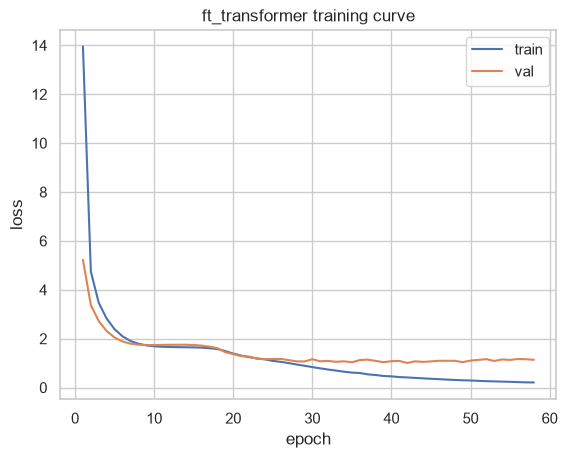

In [10]:
fig, ax = plt.subplots()
ft_logger.plot(ax=ax)
ax.set_title("ft_transformer training curve")
savefig(fig, "05_ft_transformer_training_curve.png")
plt.show()

### Save FT-Transformer embeddings

`model.embed()` (Eq. 3.9) run over `tmdb_working_train`/`tmdb_working_val`/`tmdb_working_test` in batches, under `torch.no_grad()` -- inference only, no gradient tracking needed once the model is trained. Each split's `(N, d_token)` embedding matrix is saved to `MODELS_DIR / "ft_transformer" / f"{split_name}.parquet"`, mirroring `04_feature_encoding.ipynb`'s `RAW_MODEL_DIR`/`CLASSICAL_MODEL_DIR` pattern: one row per input row, in the same order as the split's DataFrame -- no `id`/target column saved alongside, same as the raw/classical baselines, so downstream code aligns by row position against the original split parquet files. Columns are named `dim_0..dim_{d_token-1}`; there's no natural per-dimension feature name the way raw/classical's one-hot/multi-hot columns have one.

In [11]:
import torch

from src.helper import save_representation_with_id

FT_TRANSFORMER_MODEL_DIR = MODELS_DIR / "ft_transformer"
FT_TRANSFORMER_MODEL_DIR.mkdir(parents=True, exist_ok=True)

model.eval()
for split_name, df in FINAL_SPLITS.items():
    batch = fitted_encoders.transform(df)
    embedding_chunks = []
    with torch.no_grad():
        for start in range(0, len(df), ft_transformer_config.batch_size):
            end = min(start + ft_transformer_config.batch_size, len(df))
            chunk = {key: value[start:end] for key, value in batch.items()}
            embedding_chunks.append(model.embed(chunk).numpy())
    embeddings = np.concatenate(embedding_chunks, axis=0)

    embeddings_df = pd.DataFrame(
        embeddings, columns=[f"dim_{i}" for i in range(embeddings.shape[1])]
    )
    path = FT_TRANSFORMER_MODEL_DIR / f"{split_name}.parquet"
    save_representation_with_id(embeddings_df, df["id"], path)

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\ft_transformer\train.parquet (rows=8403, cols=193, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\ft_transformer\val.parquet (rows=1050, cols=193, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\ft_transformer\test.parquet (rows=1051, cols=193, id first)


### Text-free FT-Transformer (retrained, no text)

A separate `FTTransformerModel` built with `include_text=False`: `FeatureTokenizer` never builds `text_projections` for this model, so this is a full retrain from scratch, not an inference-time skip on the text-included model above -- the text-included tokenizer was fitted expecting text-shaped tokens, and simply hiding text at inference would leave it mismatched with weights that learned to use it. Saved to `MODELS_DIR / "ft_transformer_no_text" / f"{split_name}.parquet"`.

In [12]:
from src.paradigms.ft_transformer import FTTransformerModel
from src.paradigms.train_ft_transformer import train_ft_transformer

ft_transformer_model_no_text = FTTransformerModel(fitted_encoders, ft_transformer_config, include_text=False)
ft_no_text_params = sum(p.numel() for p in ft_transformer_model_no_text.parameters())
print(f"ft_transformer_no_text: total parameters: {ft_no_text_params:,}")

ft_transformer_model_no_text, ft_logger_no_text = train_ft_transformer(
    ft_transformer_model_no_text, tmdb_working_train, tmdb_working_val, fitted_encoders, ft_transformer_config,
    shared_training_config, MODELS_DIR, seed=config.RANDOM_SEED,
    include_text=False, paradigm_name="ft_transformer_no_text",
)

ft_losses_no_text_df = ft_logger_no_text.to_dataframe()
print(
    f"Epochs run: {len(ft_losses_no_text_df)} "
    f"(max_epochs={shared_training_config.max_epochs}, patience={shared_training_config.patience})"
)
print(f"Final train MSE: {ft_losses_no_text_df['train_loss'].iloc[-1]:.4f}")
print(f"Val MSE (restored/best epoch): {ft_losses_no_text_df['val_loss'].min():.4f}")

ft_transformer_no_text: total parameters: 1,599,169
Restored epoch 39's weights (val MSE: 0.9637)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\ft_transformer_no_text\diagnostics\loss_curve.csv
Epochs run: 55 (max_epochs=100, patience=16)
Final train MSE: 0.6616
Val MSE (restored/best epoch): 0.9637


In [13]:
import torch

from src.helper import save_representation_with_id

FT_TRANSFORMER_NO_TEXT_MODEL_DIR = MODELS_DIR / "ft_transformer_no_text"
FT_TRANSFORMER_NO_TEXT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

ft_transformer_model_no_text.eval()
for split_name, df in FINAL_SPLITS.items():
    batch = fitted_encoders.transform(df, include_text=False)
    embedding_chunks = []
    with torch.no_grad():
        for start in range(0, len(df), ft_transformer_config.batch_size):
            end = min(start + ft_transformer_config.batch_size, len(df))
            chunk = {key: value[start:end] for key, value in batch.items()}
            embedding_chunks.append(ft_transformer_model_no_text.embed(chunk).numpy())
    embeddings = np.concatenate(embedding_chunks, axis=0)

    embeddings_df = pd.DataFrame(
        embeddings, columns=[f"dim_{i}" for i in range(embeddings.shape[1])]
    )
    path = FT_TRANSFORMER_NO_TEXT_MODEL_DIR / f"{split_name}.parquet"
    save_representation_with_id(embeddings_df, df["id"], path)

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\ft_transformer_no_text\train.parquet (rows=8403, cols=193, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\ft_transformer_no_text\val.parquet (rows=1050, cols=193, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\ft_transformer_no_text\test.parquet (rows=1051, cols=193, id first)


## 4. SubTab

### SVD diagnostic: does 80% variance fit in 300 components?

Disposable check, nothing saved. `SubTabConfig.svd_variance_threshold` (80%) and `svd_n_components_ceiling` (300) are not yet verified against this dataset's actual multi-hot matrices. `SubTabConfig.svd_fields` (`keywords`, `production_companies`) are the two fields large enough to need SVD compression at all -- rest stay multi-hot as-is, small vocabularies. Built via `build_classical_baseline()` (Step 8's classical baseline), sliced to just each field's own multi-hot columns, on `ACTIVE_CANDIDATE`'s actual `tmdb_working_train`.

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\05\05_subtab_svd_cumulative_variance_keywords.png


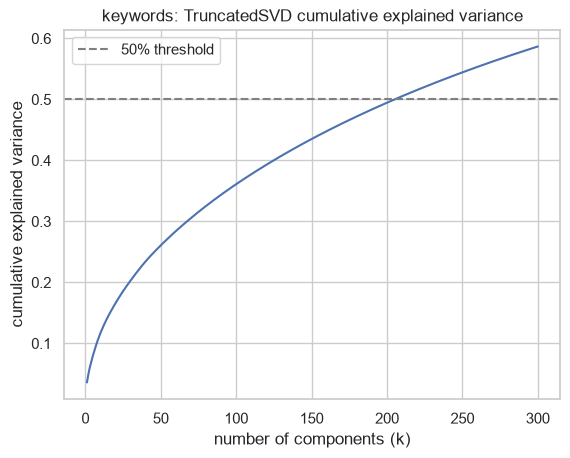

keywords: reaches 50% variance at k=206 (actual: 0.5011)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\05\05_subtab_svd_cumulative_variance_production_companies.png


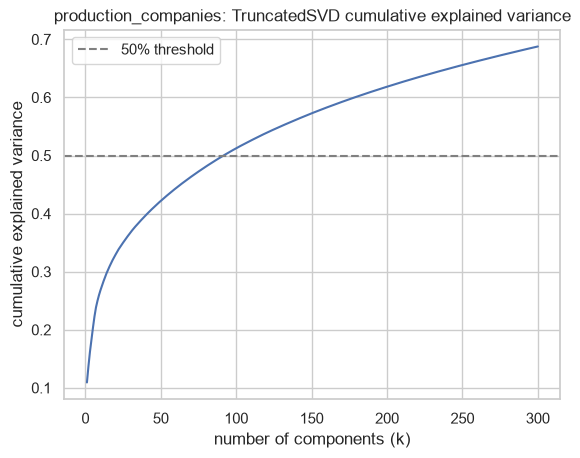

production_companies: reaches 50% variance at k=92 (actual: 0.5006)


In [14]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD

from src.features.baselines import build_classical_baseline

classical_baseline = build_classical_baseline(
    tmdb_working_train,
    train_split,
    fitted_encoders.column_groups.numeric_cols,
    fitted_encoders.standardizer,
    fitted_encoders.language_lookup,
    fitted_encoders.list_poolers,
)

for field in subtab_config.svd_fields:
    field_cols = [c for c in classical_baseline.columns if c.startswith(f"{field}_")]
    # Genuinely sparse -- each row sets only a handful of the ~2000
    # possible items -- so csr_matrix, not a dense array.
    field_matrix = csr_matrix(classical_baseline[field_cols].to_numpy())

    n_components = min(subtab_config.svd_n_components_ceiling, field_matrix.shape[1] - 1)
    # algorithm="arpack", not the default "randomized" -- randomized
    # segfaults on this sparse matrix once n_components reaches ~150 in
    # this environment (isolated separately, not specific to this data);
    # arpack is exact for this problem size and does not hit that crash.
    svd = TruncatedSVD(n_components=n_components, random_state=config.RANDOM_SEED, algorithm="arpack")
    svd.fit(field_matrix)
    cumulative_variance = np.cumsum(svd.explained_variance_ratio_)

    fig, ax = plt.subplots()
    ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
    ax.axhline(
        subtab_config.svd_variance_threshold, color="gray", linestyle="--",
        label=f"{subtab_config.svd_variance_threshold:.0%} threshold",
    )
    ax.set_xlabel("number of components (k)")
    ax.set_ylabel("cumulative explained variance")
    ax.set_title(f"{field}: TruncatedSVD cumulative explained variance")
    ax.legend()
    savefig(fig, f"05_subtab_svd_cumulative_variance_{field}.png")
    plt.show()

    reached = np.where(cumulative_variance >= subtab_config.svd_variance_threshold)[0]
    if len(reached) > 0:
        k = int(reached[0]) + 1
        print(
            f"{field}: reaches {subtab_config.svd_variance_threshold:.0%} variance "
            f"at k={k} (actual: {cumulative_variance[k-1]:.4f})"
        )
    else:
        print(
            f"{field}: {subtab_config.svd_variance_threshold:.0%} NOT reached by "
            f"k={n_components}; variance at k={n_components} is {cumulative_variance[-1]:.4f}"
        )
        # Curve-shape judgment: compare the variance gained over the last
        # 10% of components against the first 10% -- a concrete "would
        # raising the ceiling help" signal, not just eyeballing the plot.
        n = len(cumulative_variance)
        tail = max(1, n // 10)
        first_gain = cumulative_variance[tail - 1]
        last_gain = cumulative_variance[-1] - cumulative_variance[-1 - tail]
        ratio = last_gain / first_gain
        shape = "still climbing steeply" if ratio > 0.5 else "flattening out"
        print(
            f"  gain from first {tail} components: {first_gain:.4f}, "
            f"gain from last {tail} components: {last_gain:.4f} "
            f"(ratio {ratio:.2f}) -> curve is {shape}"
        )

### Fit list-field SVD reducers

Refits `SubtabListReducer` for `keywords`/`production_companies` at the exact k diagnostic settled on (`keywords=206`, `production_companies=92`) -- a fresh `TruncatedSVD(n_components=k)` fit, not a slice of the k=300 exploratory fit above, so the variance captured here is the same deterministic `arpack` fit stopped at the k actually used going forward.

In [15]:
from src.paradigms.subtab import SubtabListReducer

svd_k = {"keywords": 206, "production_companies": 92}

list_reducers = {}
for field, k in svd_k.items():
    reducer = SubtabListReducer().fit(tmdb_working_train, field, fitted_encoders, k)
    list_reducers[field] = reducer

    variance_captured = reducer.svd.explained_variance_ratio_.sum()
    print(f"{field}: k={k}, variance captured = {variance_captured:.4f}")

    for split_name, split_df in [("train", tmdb_working_train), ("val", tmdb_working_val), ("test", tmdb_working_test)]:
        transformed = reducer.transform(split_df, fitted_encoders)
        print(f"  {split_name}: shape {transformed.shape}")

keywords: k=206, variance captured = 0.5011
  train: shape (8403, 206)
  val: shape (1050, 206)
  test: shape (1051, 206)
production_companies: k=92, variance captured = 0.5006
  train: shape (8403, 92)
  val: shape (1050, 92)
  test: shape (1051, 92)


### Build flat vectors

`build_flat_vector()` concatenates every field into the fixed-order reconstruction target for SubTab's autoencoder, using the reducers fit above. `flat_vector_segment_bounds()` returns each segment's column range in that array -- printed here so the layout `per_segment_reconstruction_mse` and `train_subtab` both rely on is visible before either uses it.

In [16]:
from src.paradigms.subtab import build_flat_vector, flat_vector_segment_bounds

flat_vectors = {}
for split_name, split_df in [("train", tmdb_working_train), ("val", tmdb_working_val), ("test", tmdb_working_test)]:
    flat_vectors[split_name] = build_flat_vector(split_df, fitted_encoders, list_reducers)
    print(f"{split_name}: shape {flat_vectors[split_name].shape}")

segment_bounds = flat_vector_segment_bounds(fitted_encoders, list_reducers)
print("\nsegment bounds:")
for name, (start, end) in segment_bounds.items():
    print(f"  {name}: [{start}, {end})  width={end - start}")

build_flat_vector: total width = 2270
train: shape (8403, 2270)
build_flat_vector: total width = 2270
val: shape (1050, 2270)
build_flat_vector: total width = 2270
test: shape (1051, 2270)

segment bounds:
  numeric: [0, 168)  width=168
  original_language: [168, 175)  width=7
  genres: [175, 195)  width=20
  production_countries: [195, 319)  width=124
  spoken_languages: [319, 436)  width=117
  keywords: [436, 642)  width=206
  production_companies: [642, 734)  width=92
  overview: [734, 1502)  width=768
  original_title: [1502, 2270)  width=768


### Column subsets

`make_column_subsets()` splits the flat vector's columns into `SubTabConfig.n_subsets` overlapping, contiguous subsets -- built once here (width is fixed once `tmdb_working_train`'s flat vector exists), matching `train_subtab()`'s own once-up-front construction.

In [17]:
from src.paradigms.subtab import make_column_subsets

full_width = flat_vectors["train"].shape[1]
subsets = make_column_subsets(full_width, subtab_config.n_subsets, subtab_config.overlap)

# make_column_subsets takes contiguous ranges over FLAT_VECTOR_SEGMENT_ORDER's
# fixed column order, so later subsets can land mostly/entirely inside the two
# 768-wide SBERT text segments -- mapping each subset's range back to
# segment_bounds' segment names (computed in the cell above) makes which
# feature types actually landed in which subset visible, rather than only the
# raw column range.
def _segments_in_range(start: int, end: int) -> list[str]:
    """Segment names (from segment_bounds) whose column range overlaps [start, end)."""
    return [
        name for name, (seg_start, seg_end) in segment_bounds.items()
        if seg_start < end and seg_end > start
    ]

print(f"n_subsets={subtab_config.n_subsets}, overlap={subtab_config.overlap}, full_width={full_width}\n")
for i, s in enumerate(subsets):
    subset_start, subset_end = int(s[0]), int(s[-1]) + 1
    segments = _segments_in_range(subset_start, subset_end)
    print(f"subset {i}: size={len(s)}, range=[{s[0]}, {s[-1]}], segments={segments}")
    if i > 0:
        overlap_with_prev = len(set(s.tolist()) & set(subsets[i - 1].tolist()))
        print(f"  overlap with subset {i - 1}: {overlap_with_prev} columns")

n_subsets=5, overlap=0.25, full_width=2270

subset 0: size=567, range=[0, 566], segments=['numeric', 'original_language', 'genres', 'production_countries', 'spoken_languages', 'keywords']
subset 1: size=567, range=[341, 907], segments=['spoken_languages', 'keywords', 'production_companies', 'overview']
  overlap with subset 0: 226 columns
subset 2: size=567, range=[795, 1361], segments=['overview']
  overlap with subset 1: 113 columns
subset 3: size=567, range=[1249, 1815], segments=['overview', 'original_title']
  overlap with subset 2: 113 columns
subset 4: size=567, range=[1703, 2269], segments=['original_title']
  overlap with subset 3: 113 columns


### Instantiate SubTabAutoencoder

One shared encoder/decoder pair, sized from `subtab_config.encoder_dims`/`latent_dim` (Uçar et al.'s Income/Obesity architecture) and this dataset's actual `subset_width`/`full_width`.

In [18]:
from src.paradigms.subtab import SubTabAutoencoder

subset_width = len(subsets[0])
subtab_model = SubTabAutoencoder(subset_width=subset_width, full_width=full_width, config=subtab_config)

n_params = sum(p.numel() for p in subtab_model.parameters())
print(f"SubTabAutoencoder: subset_width={subset_width}, full_width={full_width}")
print(f"parameter count: {n_params:,}")

SubTabAutoencoder: subset_width=567, full_width=2270
parameter count: 5,007,582


### Train SubTab

`train_subtab()` trains against `reconstruction_loss` (L_r only, no L_c/L_d -- D28) with early stopping on val L_r, restoring the best epoch's weights -- same discipline as FT-Transformer's own trainer above. Also reports `per_segment_reconstruction_mse`'s per-segment MSE (one value per `FLAT_VECTOR_SEGMENT_ORDER` entry) at that same restored epoch, not the final epoch trained.

In [19]:
from src.paradigms.train_subtab import train_subtab

subtab_model, subtab_logger, subtab_val_segment_mse = train_subtab(
    subtab_model, tmdb_working_train, tmdb_working_val, fitted_encoders, list_reducers, subtab_config,
    shared_training_config, MODELS_DIR,
    seed=config.RANDOM_SEED,
)

subtab_losses_df = subtab_logger.to_dataframe()
print(
    f"Epochs run: {len(subtab_losses_df)} "
    f"(max_epochs={shared_training_config.max_epochs}, patience={shared_training_config.patience})"
)
print(f"Final train L_r: {subtab_losses_df['train_loss'].iloc[-1]:.4f}")
print(f"Val L_r (restored/best epoch): {subtab_losses_df['val_loss'].min():.4f}")

best_epoch = int(subtab_losses_df['val_loss'].idxmin()) + 1
restored_seg = subtab_val_segment_mse[best_epoch - 1]
print(f"Restored epoch {best_epoch} per-segment MSE:")
for name, mse in restored_seg.items():
    print(f"  {name}: {mse:.4f}")

build_flat_vector: total width = 2270
build_flat_vector: total width = 2270
Restored epoch 8's weights (val L_r: 0.0166)
  at restored epoch, per-segment MSE:
    numeric: 0.1175
    original_language: 0.0337
    genres: 0.0718
    production_countries: 0.0057
    spoken_languages: 0.0056
    keywords: 0.0108
    production_companies: 0.0110
    overview: 0.0069
    original_title: 0.0082
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\subtab\diagnostics\loss_curve.csv
Epochs run: 24 (max_epochs=100, patience=16)
Final train L_r: 0.0102
Val L_r (restored/best epoch): 0.0166
Restored epoch 8 per-segment MSE:
  numeric: 0.1175
  original_language: 0.0337
  genres: 0.0718
  production_countries: 0.0057
  spoken_languages: 0.0056
  keywords: 0.0108
  production_companies: 0.0110
  overview: 0.0069
  original_title: 0.0082


### Save SubTab embeddings

Encodes all `SubTabConfig.n_subsets` subsets per row via `subtab_model.encoder` (skipping the decoder -- only the latent is needed here) and mean-aggregates them into one `(N, latent_dim)` vector per row. This is Eq. 3.11's own inference-time rule (Uçar et al.'s §2.3 "Test time": "we feed the subsets of test set to the encoder, and get the aggregate of the representations of all available subsets" -- mean aggregation, `SubTabConfig.aggregation="mean"`), not a new choice made here. Each split's embedding matrix is saved to `MODELS_DIR / "subtab" / f"{split_name}.parquet"`, mirroring FT-Transformer's own save cell above and `04_feature_encoding.ipynb`'s `RAW_MODEL_DIR`/`CLASSICAL_MODEL_DIR` pattern.

In [20]:
import torch

from src.helper import save_representation_with_id

SUBTAB_MODEL_DIR = MODELS_DIR / "subtab"
SUBTAB_MODEL_DIR.mkdir(parents=True, exist_ok=True)

subset_tensors = [torch.from_numpy(s).long() for s in subsets]

subtab_model.eval()
for split_name, df in FINAL_SPLITS.items():
    flat_t = torch.from_numpy(flat_vectors[split_name]).float()
    embedding_chunks = []
    with torch.no_grad():
        for start in range(0, len(df), subtab_config.batch_size):
            end = min(start + subtab_config.batch_size, len(df))
            chunk = flat_t[start:end]
            subset_latents = [subtab_model.encoder(chunk[:, s]) for s in subset_tensors]
            # Eq. 3.11's own test-time rule -- mean aggregation across
            # all K subsets' latents (Ucar et al. SS2.3 "Test time"),
            # not a new choice made here.
            mean_latent = torch.stack(subset_latents, dim=0).mean(dim=0)
            embedding_chunks.append(mean_latent.numpy())
    embeddings = np.concatenate(embedding_chunks, axis=0)

    embeddings_df = pd.DataFrame(
        embeddings, columns=[f"dim_{i}" for i in range(embeddings.shape[1])]
    )
    path = SUBTAB_MODEL_DIR / f"{split_name}.parquet"
    save_representation_with_id(embeddings_df, df["id"], path)

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\subtab\train.parquet (rows=8403, cols=1025, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\subtab\val.parquet (rows=1050, cols=1025, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\subtab\test.parquet (rows=1051, cols=1025, id first)


### Text-free SubTab (retrained, no text)

A separate `SubTabAutoencoder` trained from scratch on `build_flat_vector(..., include_text=False)`'s narrower reconstruction target -- `overview`/`original_title` never enter the flat vector, so the encoder/decoder are structurally smaller (`full_width` drops accordingly), not just the same model asked to ignore two segments at inference. `list_reducers` (fit above on `keywords`/`production_companies`, both list fields, unrelated to text) is reused unchanged. Saved to `MODELS_DIR / "subtab_no_text" / f"{split_name}.parquet"`.

In [21]:
from src.paradigms.subtab import SubTabAutoencoder, build_flat_vector, flat_vector_segment_bounds, make_column_subsets
from src.paradigms.train_subtab import train_subtab

flat_vectors_no_text = {}
for split_name, split_df in [("train", tmdb_working_train), ("val", tmdb_working_val), ("test", tmdb_working_test)]:
    flat_vectors_no_text[split_name] = build_flat_vector(
        split_df, fitted_encoders, list_reducers, include_text=False
    )
    print(f"{split_name}: shape {flat_vectors_no_text[split_name].shape}")

full_width_no_text = flat_vectors_no_text["train"].shape[1]
subsets_no_text = make_column_subsets(full_width_no_text, subtab_config.n_subsets, subtab_config.overlap)
subset_width_no_text = len(subsets_no_text[0])

subtab_model_no_text = SubTabAutoencoder(
    subset_width=subset_width_no_text, full_width=full_width_no_text, config=subtab_config
)
n_params_no_text = sum(p.numel() for p in subtab_model_no_text.parameters())
print(f"subtab_no_text: subset_width={subset_width_no_text}, full_width={full_width_no_text}")
print(f"parameter count: {n_params_no_text:,}")

subtab_model_no_text, subtab_logger_no_text, subtab_val_segment_mse_no_text = train_subtab(
    subtab_model_no_text, tmdb_working_train, tmdb_working_val, fitted_encoders, list_reducers, subtab_config,
    shared_training_config, MODELS_DIR, seed=config.RANDOM_SEED,
    include_text=False, paradigm_name="subtab_no_text",
)

subtab_losses_no_text_df = subtab_logger_no_text.to_dataframe()
print(
    f"Epochs run: {len(subtab_losses_no_text_df)} "
    f"(max_epochs={shared_training_config.max_epochs}, patience={shared_training_config.patience})"
)
print(f"Final train L_r: {subtab_losses_no_text_df['train_loss'].iloc[-1]:.4f}")
print(f"Val L_r (restored/best epoch): {subtab_losses_no_text_df['val_loss'].min():.4f}")

build_flat_vector: total width = 734
train: shape (8403, 734)
build_flat_vector: total width = 734
val: shape (1050, 734)
build_flat_vector: total width = 734
test: shape (1051, 734)
subtab_no_text: subset_width=182, full_width=734
parameter count: 3,038,942
build_flat_vector: total width = 734
build_flat_vector: total width = 734
Restored epoch 19's weights (val L_r: 0.0289)
  at restored epoch, per-segment MSE:
    numeric: 0.0929
    original_language: 0.0207
    genres: 0.0631
    production_countries: 0.0048
    spoken_languages: 0.0048
    keywords: 0.0101
    production_companies: 0.0102
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\subtab_no_text\diagnostics\loss_curve.csv
Epochs run: 35 (max_epochs=100, patience=16)
Final train L_r: 0.0227
Val L_r (restored/best epoch): 0.0289


In [22]:
import torch

from src.helper import save_representation_with_id

SUBTAB_NO_TEXT_MODEL_DIR = MODELS_DIR / "subtab_no_text"
SUBTAB_NO_TEXT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

subset_tensors_no_text = [torch.from_numpy(s).long() for s in subsets_no_text]

subtab_model_no_text.eval()
for split_name, df in FINAL_SPLITS.items():
    flat_t = torch.from_numpy(flat_vectors_no_text[split_name]).float()
    embedding_chunks = []
    with torch.no_grad():
        for start in range(0, len(df), subtab_config.batch_size):
            end = min(start + subtab_config.batch_size, len(df))
            chunk = flat_t[start:end]
            subset_latents = [subtab_model_no_text.encoder(chunk[:, s]) for s in subset_tensors_no_text]
            mean_latent = torch.stack(subset_latents, dim=0).mean(dim=0)
            embedding_chunks.append(mean_latent.numpy())
    embeddings = np.concatenate(embedding_chunks, axis=0)

    embeddings_df = pd.DataFrame(
        embeddings, columns=[f"dim_{i}" for i in range(embeddings.shape[1])]
    )
    path = SUBTAB_NO_TEXT_MODEL_DIR / f"{split_name}.parquet"
    save_representation_with_id(embeddings_df, df["id"], path)

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\subtab_no_text\train.parquet (rows=8403, cols=1025, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\subtab_no_text\val.parquet (rows=1050, cols=1025, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\subtab_no_text\test.parquet (rows=1051, cols=1025, id first)


## 5. SCARF

### Corruption sanity check

Corrupts a small sample of `tmdb_working_train` at `scarf_config.corruption_rate` (0.6) via `corrupt_dataframe()`, then prints the actual fraction of rows that differ per eligible raw column -- each is an independent Bernoulli(`p`) draw, so the observed fraction should land *close to* 0.6, not exactly 0.6. Also confirms `id`/`overview`/`original_title` come through byte-for-byte unchanged, since none of the three is a `corruption_eligible_cols` key.

In [23]:
from src.paradigms.scarf import corrupt_dataframe

CORRUPTION_SAMPLE_N = 300
corruption_sample_df = tmdb_working_train.iloc[:CORRUPTION_SAMPLE_N].reset_index(drop=True)
corruption_rng = np.random.default_rng(config.RANDOM_SEED)
corrupted_sample_df = corrupt_dataframe(
    corruption_sample_df, fitted_encoders, p=scarf_config.corruption_rate, rng=corruption_rng
)

# corruption_eligible_cols' group keys, expanded to raw df columns the
# same way corrupt_dataframe() itself does internally.
eligible_raw_cols = []
for key in fitted_encoders.corruption_eligible_cols:
    if key == "numeric":
        eligible_raw_cols.extend(fitted_encoders.column_groups.numeric_cols)
        eligible_raw_cols.extend(fitted_encoders.column_groups.bypass_cols)
    elif key == "original_language":
        eligible_raw_cols.append(fitted_encoders.language_lookup.col)
    else:
        eligible_raw_cols.append(fitted_encoders.list_poolers[key].col)


def _values_differ(a, b) -> bool:
    if pd.api.types.is_list_like(a):
        return list(a) != list(b)
    return a != b


print(f"corruption rate p = {scarf_config.corruption_rate}, sample size = {CORRUPTION_SAMPLE_N}\n")
for col in eligible_raw_cols:
    n_diff = sum(
        _values_differ(o, c)
        for o, c in zip(corruption_sample_df[col], corrupted_sample_df[col])
    )
    frac = n_diff / CORRUPTION_SAMPLE_N
    print(f"  {col}: {n_diff}/{CORRUPTION_SAMPLE_N} differ (observed fraction {frac:.3f})")

print()
for col in ["id", "overview", "original_title"]:
    unchanged = (corruption_sample_df[col] == corrupted_sample_df[col]).all()
    print(f"{col} byte-for-byte unchanged: {unchanged}")
    assert unchanged, f"{col} should never be corrupted"

corruption rate p = 0.6, sample size = 300

  revenue: 185/300 differ (observed fraction 0.617)
  runtime: 169/300 differ (observed fraction 0.563)
  budget: 174/300 differ (observed fraction 0.580)
  popularity: 190/300 differ (observed fraction 0.633)
  release_year: 165/300 differ (observed fraction 0.550)
  has_genres: 2/300 differ (observed fraction 0.007)
  has_keywords: 15/300 differ (observed fraction 0.050)
  has_production_companies: 21/300 differ (observed fraction 0.070)
  has_production_countries: 13/300 differ (observed fraction 0.043)
  has_spoken_languages: 13/300 differ (observed fraction 0.043)
  has_overview: 1/300 differ (observed fraction 0.003)
  release_month_sin: 169/300 differ (observed fraction 0.563)
  release_month_cos: 181/300 differ (observed fraction 0.603)
  title_differs_from_original: 59/300 differ (observed fraction 0.197)
  original_language: 72/300 differ (observed fraction 0.240)
  genres: 187/300 differ (observed fraction 0.623)
  production_compa

`ScarfEmbeddingTables`, `ScarfEncoder` (`f`), and `ScarfProjectionHead` (`g`) -- all three are jointly trained by `train_scarf()` below, so their combined parameter count is printed together.

In [24]:
from src.paradigms.scarf import (
    ScarfEmbeddingTables,
    ScarfEncoder,
    ScarfProjectionHead,
    build_scarf_flat_vector,
    DEFAULT_E_DIM,
)

scarf_tables = ScarfEmbeddingTables(fitted_encoders, e_dim=DEFAULT_E_DIM)

# build_scarf_flat_vector's width is a fixed function of fitted_encoders/
# scarf_tables, not of which/how-many rows are passed -- a 2-row slice is
# enough to read off ScarfEncoder's required input_dim.
_sample_transformed = fitted_encoders.transform(tmdb_working_train.iloc[:2])
scarf_flat_width = build_scarf_flat_vector(_sample_transformed, scarf_tables, fitted_encoders).shape[1]

scarf_encoder = ScarfEncoder(input_dim=scarf_flat_width, config=scarf_config)
scarf_encoder_output_dim = scarf_encoder.net[-1].out_features
scarf_head = ScarfProjectionHead(input_dim=scarf_encoder_output_dim, config=scarf_config)

tables_params = sum(p.numel() for p in scarf_tables.parameters())
encoder_params = sum(p.numel() for p in scarf_encoder.parameters())
head_params = sum(p.numel() for p in scarf_head.parameters())

print(f"scarf_flat_width: {scarf_flat_width}")
print(f"scarf_encoder_output_dim: {scarf_encoder_output_dim}")
print(f"ScarfEmbeddingTables params: {tables_params:,}")
print(f"ScarfEncoder params: {encoder_params:,}")
print(f"ScarfProjectionHead params: {head_params:,}")
print(f"total parameters: {tables_params + encoder_params + head_params:,}")

scarf_flat_width: 2671
scarf_encoder_output_dim: 256
ScarfEmbeddingTables params: 818,880
ScarfEncoder params: 881,408
ScarfProjectionHead params: 131,584
total parameters: 1,831,872


### Train SCARF

`train_scarf()` jointly trains `scarf_tables`/`scarf_encoder`/`scarf_head` against `nt_xent_loss` (Eq. 3.14-3.15), with early stopping on validation NT-Xent using `shared_training_config.patience` -- NOT Bahri et al.'s own reported patience of 3 (see `train_scarf.py`'s module docstring, D12).

In [25]:
from src.paradigms.train_scarf import train_scarf

scarf_tables, scarf_encoder, scarf_head, scarf_logger = train_scarf(
    scarf_tables,
    scarf_encoder,
    scarf_head,
    tmdb_working_train,
    tmdb_working_val,
    fitted_encoders,
    scarf_config,
    shared_training_config,
    MODELS_DIR,
    seed=config.RANDOM_SEED,
)

scarf_losses_df = scarf_logger.to_dataframe()
print(
    f"Epochs run: {len(scarf_losses_df)} "
    f"(max_epochs={shared_training_config.max_epochs}, patience={shared_training_config.patience})"
)
print(f"Final train NT-Xent: {scarf_losses_df['train_loss'].iloc[-1]:.4f}")
print(f"Val NT-Xent (restored/best epoch): {scarf_losses_df['val_loss'].min():.4f}")

Restored epoch 37's weights (val NT-Xent: 3.8485)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\scarf\diagnostics\loss_curve.csv
Epochs run: 53 (max_epochs=100, patience=16)
Final train NT-Xent: 3.9662
Val NT-Xent (restored/best epoch): 3.8485


### Save SCARF embeddings

Chapter 4's representation is `f`'s output only (Eq. 3.13) -- `g` (`scarf_head`) is discarded here, matching Bahri et al. (2022)'s own "after pre-training, g is discarded" rule (`ScarfProjectionHead`'s own docstring). Runs the UNCORRUPTED flat vector through `scarf_tables` + `scarf_encoder` only -- corruption is a training-time augmentation, not something applied at inference. Each split's `(N, scarf_encoder_output_dim)` embedding matrix is saved to `MODELS_DIR / "scarf" / f"{split_name}.parquet"`, mirroring FT-Transformer's/SubTab's own save cells above.

In [26]:
import torch

from src.helper import save_representation_with_id

SCARF_MODEL_DIR = MODELS_DIR / "scarf"
SCARF_MODEL_DIR.mkdir(parents=True, exist_ok=True)

scarf_tables.eval()
scarf_encoder.eval()
for split_name, df in FINAL_SPLITS.items():
    embedding_chunks = []
    with torch.no_grad():
        for start in range(0, len(df), scarf_config.batch_size):
            end = min(start + scarf_config.batch_size, len(df))
            chunk_df = df.iloc[start:end]
            transformed = fitted_encoders.transform(chunk_df)
            flat_vec = build_scarf_flat_vector(transformed, scarf_tables, fitted_encoders)
            embedding_chunks.append(scarf_encoder(flat_vec).numpy())
    embeddings = np.concatenate(embedding_chunks, axis=0)

    embeddings_df = pd.DataFrame(
        embeddings, columns=[f"dim_{i}" for i in range(embeddings.shape[1])]
    )
    path = SCARF_MODEL_DIR / f"{split_name}.parquet"
    save_representation_with_id(embeddings_df, df["id"], path)

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\scarf\train.parquet (rows=8403, cols=257, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\scarf\val.parquet (rows=1050, cols=257, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\scarf\test.parquet (rows=1051, cols=257, id first)


### Text-free SCARF (retrained, no text)

A fresh `ScarfEmbeddingTables`/`ScarfEncoder`/`ScarfProjectionHead` trained from scratch on `build_scarf_flat_vector(..., include_text=False)`'s narrower flat vector -- `ScarfEncoder`'s `input_dim` is fixed at construction from that narrower width, so this is a structurally smaller encoder, not the text-included encoder asked to ignore two segments. `build_scarf_views`' own `include_text` flag now genuinely excludes text from both the clean and corrupted views (a real fix, not just a new argument: it previously accepted `include_text` implicitly via `text_vectors is None` but never passed it on to `build_scarf_flat_vector`, so the text-included default always won regardless). Saved to `MODELS_DIR / "scarf_no_text" / f"{split_name}.parquet"`.

In [27]:
from src.paradigms.scarf import (
    ScarfEmbeddingTables,
    ScarfEncoder,
    ScarfProjectionHead,
    build_scarf_flat_vector,
    DEFAULT_E_DIM,
)
from src.paradigms.train_scarf import train_scarf

scarf_tables_no_text = ScarfEmbeddingTables(fitted_encoders, e_dim=DEFAULT_E_DIM)

_sample_transformed_no_text = fitted_encoders.transform(tmdb_working_train.iloc[:2], include_text=False)
scarf_flat_width_no_text = build_scarf_flat_vector(
    _sample_transformed_no_text, scarf_tables_no_text, fitted_encoders, include_text=False
).shape[1]

scarf_encoder_no_text = ScarfEncoder(input_dim=scarf_flat_width_no_text, config=scarf_config)
scarf_encoder_no_text_output_dim = scarf_encoder_no_text.net[-1].out_features
scarf_head_no_text = ScarfProjectionHead(input_dim=scarf_encoder_no_text_output_dim, config=scarf_config)

tables_params_no_text = sum(p.numel() for p in scarf_tables_no_text.parameters())
encoder_params_no_text = sum(p.numel() for p in scarf_encoder_no_text.parameters())
head_params_no_text = sum(p.numel() for p in scarf_head_no_text.parameters())

print(f"scarf_flat_width (no text): {scarf_flat_width_no_text}")
print(f"total parameters: {tables_params_no_text + encoder_params_no_text + head_params_no_text:,}")

scarf_tables_no_text, scarf_encoder_no_text, scarf_head_no_text, scarf_logger_no_text = train_scarf(
    scarf_tables_no_text,
    scarf_encoder_no_text,
    scarf_head_no_text,
    tmdb_working_train,
    tmdb_working_val,
    fitted_encoders,
    scarf_config,
    shared_training_config,
    MODELS_DIR,
    seed=config.RANDOM_SEED,
    include_text=False,
    paradigm_name="scarf_no_text",
)

scarf_losses_no_text_df = scarf_logger_no_text.to_dataframe()
print(
    f"Epochs run: {len(scarf_losses_no_text_df)} "
    f"(max_epochs={shared_training_config.max_epochs}, patience={shared_training_config.patience})"
)
print(f"Final train NT-Xent: {scarf_losses_no_text_df['train_loss'].iloc[-1]:.4f}")
print(f"Val NT-Xent (restored/best epoch): {scarf_losses_no_text_df['val_loss'].min():.4f}")

scarf_flat_width (no text): 1135
total parameters: 1,438,656
Restored epoch 90's weights (val NT-Xent: 4.3039)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\scarf_no_text\diagnostics\loss_curve.csv
Epochs run: 100 (max_epochs=100, patience=16)
Final train NT-Xent: 4.3391
Val NT-Xent (restored/best epoch): 4.3039


In [28]:
import torch

from src.helper import save_representation_with_id

SCARF_NO_TEXT_MODEL_DIR = MODELS_DIR / "scarf_no_text"
SCARF_NO_TEXT_MODEL_DIR.mkdir(parents=True, exist_ok=True)

scarf_tables_no_text.eval()
scarf_encoder_no_text.eval()
for split_name, df in FINAL_SPLITS.items():
    embedding_chunks = []
    with torch.no_grad():
        for start in range(0, len(df), scarf_config.batch_size):
            end = min(start + scarf_config.batch_size, len(df))
            chunk_df = df.iloc[start:end]
            transformed = fitted_encoders.transform(chunk_df, include_text=False)
            flat_vec = build_scarf_flat_vector(
                transformed, scarf_tables_no_text, fitted_encoders, include_text=False
            )
            embedding_chunks.append(scarf_encoder_no_text(flat_vec).numpy())
    embeddings = np.concatenate(embedding_chunks, axis=0)

    embeddings_df = pd.DataFrame(
        embeddings, columns=[f"dim_{i}" for i in range(embeddings.shape[1])]
    )
    path = SCARF_NO_TEXT_MODEL_DIR / f"{split_name}.parquet"
    save_representation_with_id(embeddings_df, df["id"], path)

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\scarf_no_text\train.parquet (rows=8403, cols=257, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\scarf_no_text\val.parquet (rows=1050, cols=257, id first)
Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\models\br_gt0\scarf_no_text\test.parquet (rows=1051, cols=257, id first)


## 6. Cross-paradigm training diagnostics

Loads each paradigm's saved `loss_curve.csv` (written by `TrainingLogger.save()` during training above) and plots all three on one shared figure via `TrainingLogger.plot()`'s identical axes/styling -- comparable side by side despite their different loss units. Also prints a plain trend read on each paradigm's most recent validation-loss epochs. This does NOT decide anything about promoting `nbr_gt5` -- that call is made by hand from these numbers, not automated here.

ft_transformer: 58 epochs run
  final train_loss=0.2068, final val_loss=1.1335
  last 5 val_loss values: [1.0875, 1.1491, 1.13, 1.1665, 1.1581, 1.1335]
  diagnostic: val loss increasing

subtab: 24 epochs run
  final train_loss=0.0102, final val_loss=0.0172
  last 5 val_loss values: [0.017, 0.0171, 0.017, 0.0171, 0.017, 0.0172]
  diagnostic: val loss increasing

scarf: 53 epochs run
  final train_loss=3.9662, final val_loss=3.8942
  last 5 val_loss values: [3.8803, 3.871, 3.8672, 3.8632, 3.9562, 3.8942]
  diagnostic: val loss flat for the last 5 epochs

Saved: C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\figures\05\05_cross_paradigm_training_curves.png


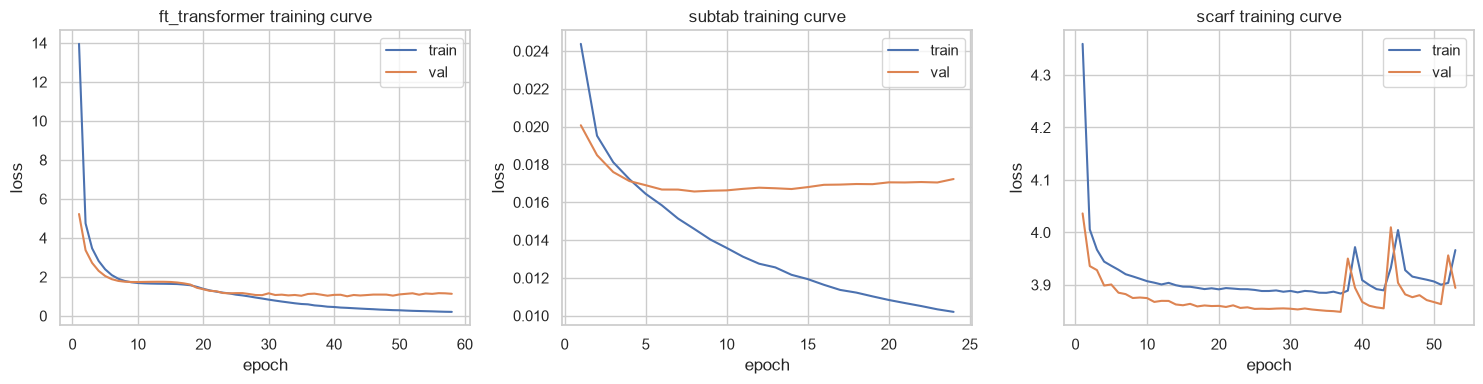

In [29]:
from src.paradigms.training_diagnostics import TrainingLogger

PARADIGMS = ["ft_transformer", "subtab", "scarf"]
TREND_WINDOW = 5
# relative change in val_loss over the trend window -- a readability
# cutoff for the printed message below, not paper-sourced.
TREND_THRESHOLD = 0.01

fig, axes = plt.subplots(1, len(PARADIGMS), figsize=(15, 4))

for ax, paradigm_name in zip(axes, PARADIGMS):
    csv_path = MODELS_DIR / paradigm_name / "diagnostics" / "loss_curve.csv"
    loaded_df = pd.read_csv(csv_path)

    paradigm_logger = TrainingLogger()
    for row in loaded_df.itertuples(index=False):
        paradigm_logger.log(row.epoch, row.train_loss, row.val_loss)
    paradigm_logger.plot(ax=ax)
    ax.set_title(f"{paradigm_name} training curve")

    val_loss = loaded_df["val_loss"]
    window = min(TREND_WINDOW, len(loaded_df) - 1)
    if window <= 0:
        trend_message = "not enough epochs to assess trend"
        recent_values = val_loss.round(4).tolist()
    else:
        recent = val_loss.iloc[-(window + 1):]
        recent_values = recent.round(4).tolist()
        first, last = recent.iloc[0], recent.iloc[-1]
        rel_change = (last - first) / abs(first) if first != 0 else (last - first)
        if rel_change < -TREND_THRESHOLD:
            trend_message = "val loss still decreasing at last epoch"
        elif rel_change > TREND_THRESHOLD:
            trend_message = "val loss increasing"
        else:
            trend_message = f"val loss flat for the last {window} epochs"

    print(f"{paradigm_name}: {len(loaded_df)} epochs run")
    print(
        f"  final train_loss={loaded_df['train_loss'].iloc[-1]:.4f}, "
        f"final val_loss={val_loss.iloc[-1]:.4f}"
    )
    print(f"  last {max(window, 0)} val_loss values: {recent_values}")
    print(f"  diagnostic: {trend_message}\n")

plt.tight_layout()
savefig(fig, "05_cross_paradigm_training_curves.png")
plt.show()

## 7. Log summary

In [30]:
from src.report import log_findings

EMBEDDING_PARADIGMS_LOG_PATH = config.REPORTS_DIR / "embedding_paradigms_log.md"

findings = {
    "Active candidate": ACTIVE_CANDIDATE,
    "FT-Transformer": {
        "parameters": total_params,
        "epochs run": len(ft_losses_df),
        "final train MSE": round(ft_losses_df["train_loss"].iloc[-1], 4),
        "val MSE (restored/best epoch)": round(ft_losses_df["val_loss"].min(), 4),
    },
    "FT-Transformer (text-free)": {
        "parameters": ft_no_text_params,
        "epochs run": len(ft_losses_no_text_df),
        "final train MSE": round(ft_losses_no_text_df["train_loss"].iloc[-1], 4),
        "val MSE (restored/best epoch)": round(ft_losses_no_text_df["val_loss"].min(), 4),
    },
    "SubTab": {
        "subset_width": subset_width,
        "full_width": full_width,
        "parameters": n_params,
        "epochs run": len(subtab_losses_df),
        "val L_r (restored/best epoch)": round(subtab_losses_df["val_loss"].min(), 4),
    },
    "SubTab (text-free)": {
        "subset_width": subset_width_no_text,
        "full_width": full_width_no_text,
        "parameters": n_params_no_text,
        "epochs run": len(subtab_losses_no_text_df),
        "val L_r (restored/best epoch)": round(subtab_losses_no_text_df["val_loss"].min(), 4),
    },
    "SCARF": {
        "flat_width": scarf_flat_width,
        "parameters": tables_params + encoder_params + head_params,
        "epochs run": len(scarf_losses_df),
        "val NT-Xent (restored/best epoch)": round(scarf_losses_df["val_loss"].min(), 4),
    },
    "SCARF (text-free)": {
        "flat_width": scarf_flat_width_no_text,
        "parameters": tables_params_no_text + encoder_params_no_text + head_params_no_text,
        "epochs run": len(scarf_losses_no_text_df),
        "val NT-Xent (restored/best epoch)": round(scarf_losses_no_text_df["val_loss"].min(), 4),
    },
    "Saved embeddings": (
        f"train/val/test parquet files under {MODELS_DIR}, id column first, for "
        "ft_transformer/subtab/scarf and their _no_text counterparts"
    ),
}

log_findings(
    title="05 Embedding Paradigms: TMDB -- summary",
    findings=findings,
    figures=[
        "reports/figures/05/05_ft_transformer_training_curve.png",
        "reports/figures/05/05_subtab_svd_cumulative_variance_keywords.png",
        "reports/figures/05/05_subtab_svd_cumulative_variance_production_companies.png",
        "reports/figures/05/05_cross_paradigm_training_curves.png",
    ],
    log_path=EMBEDDING_PARADIGMS_LOG_PATH,
    log_title="Embedding Paradigms Log",
)
print(f"Logged summary to {EMBEDDING_PARADIGMS_LOG_PATH}")

Logged summary to C:\Users\knowu\Documents\Project-Repos\Dissertation\smart-tabular-embeddings\reports\embedding_paradigms_log.md
